# Day 11 — Outlier Detection: ML Ensemble Methods
## Week 2: Outlier Detection | Digital Consumer Platform Analytics

---

### Learning Objectives
- Understand IForest, LOF, KNN, HBOS, CBLOF from first principles
- Know the mathematical basis for each detector's anomaly score
- Understand why ensembles outperform individual detectors
- Know how to score standardization enables ensemble averaging
- Build the decision framework: which detector for which situation

---

### Dataset
**Credit Card Fraud** — continuing from Day 10. Today adds ML detectors.

---

## Part 1: Theory

### 11.1 Isolation Forest

**Key insight:** Anomalies are easier to isolate than normal points.

**Algorithm:**
1. Build many isolation trees by randomly selecting a feature and a random split value
2. Measure path length: how many splits needed to isolate each point?
3. Anomaly score: shorter path length = easier to isolate = more anomalous

**Expected path length for a normal point in a dataset of size $n$:**
$$c(n) = 2H(n-1) - \frac{2(n-1)}{n}$$

Where $H(i)$ is the harmonic number.

**Anomaly score:**
$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$

Where $E[h(x)]$ is the average path length across all trees.

- $s \approx 1$: very short path = anomaly
- $s \approx 0.5$: average path = normal
- $s \approx 0$: very long path = definitely normal

**Why it works:** Anomalies are sparse and different from most data — they get isolated in early splits. Normal points are dense — they require many splits to isolate.

**Complexity:** $O(n \log n)$ — scales well to large datasets. This is why it's in our production pipeline.

---

### 11.2 Local Outlier Factor (LOF)

**Key insight:** Anomalies have lower local density than their neighbors.

**Algorithm:**

Step 1: For each point $p$, find its $k$ nearest neighbors $N_k(p)$.

Step 2: Compute reachability distance (smoothed distance):
$$\text{reach-dist}_k(p, o) = \max(k\text{-dist}(o), d(p, o))$$

This smoothing prevents very close points from having near-zero distances.

Step 3: Compute local reachability density:
$$\text{lrd}_k(p) = \frac{|N_k(p)|}{\sum_{o \in N_k(p)} \text{reach-dist}_k(p, o)}$$

Step 4: Compute LOF score:
$$\text{LOF}_k(p) = \frac{\sum_{o \in N_k(p)} \frac{\text{lrd}_k(o)}{\text{lrd}_k(p)}}{|N_k(p)|}$$

**Interpretation:**
- $LOF \approx 1$: similar density to neighbors = normal
- $LOF >> 1$: much lower density than neighbors = outlier

**Advantage over global methods:** LOF is local — it can detect outliers in datasets where different regions have different densities. A point in a sparse region may be normal (if its neighbors are also sparse), while a point in a dense region may be anomalous (if it's noticeably less dense than its neighbors).

**Complexity:** $O(n^2)$ — slow on large datasets. Use HBOS or IForest above 100K rows.

---

### 11.3 HBOS — Histogram-Based Outlier Score

**Key insight:** Anomalies appear in low-density histogram bins.

**Algorithm:**
1. For each feature, build a histogram (bin the values)
2. Compute the frequency (density) of each bin
3. For each point, look up its bin frequency for each feature
4. Anomaly score = product of inverse bin frequencies across features:

$$\text{HBOS}(x) = \sum_{i=1}^d \log \frac{1}{\text{hist}_i(x_i)}$$

(Sum of logs = log of product — numerically more stable)

**Assumption:** Features are independent. This is HBOS's key limitation — it ignores correlations. But it makes it extremely fast: $O(nd)$.

**When to use:** Large datasets where IForest is too slow, or when features are approximately independent.

---

### 11.4 CBLOF — Cluster-Based Local Outlier Factor

**Key insight:** Anomalies are far from any cluster center and belong to small clusters.

**Algorithm:**
1. Cluster the data (typically KMeans)
2. Classify clusters as "large" or "small" (threshold: e.g. top 90% of data mass)
3. For points in **large clusters**: score = distance to cluster center × cluster size
4. For points in **small clusters**: score = distance to nearest large cluster center × small cluster size

**Intuition:** Being far from a large cluster center is suspicious. Being in a tiny cluster is suspicious (small cluster = might be a group of anomalies).

**Limitation:** Requires clustering first — CBLOF quality depends on cluster quality. Fails when clusters have very irregular shapes. Can fail on very high-dimensional data when clustering itself is unreliable.

---

### 11.5 PyOD KNN

PyOD's KNN detector uses the distance to the k-th nearest neighbor as the anomaly score:

$$	ext{score}(x) = d(x, x_{(k)})$$

Where $x_{(k)}$ is the k-th nearest neighbor.

High distance to k-th neighbor = isolated point = anomaly.

Variants:
- **largest**: use distance to k-th neighbor (default)
- **mean**: use mean distance to k nearest neighbors
- **median**: use median distance

---

### 11.6 Ensemble Averaging

Individual detectors have complementary strengths:
- IForest: global anomalies, scales well
- LOF: local density anomalies, complex shapes
- HBOS: fast, independent features
- CBLOF: cluster-aware, density-based

**Why average?** Each detector sees a different "view" of anomalousness. Averaging reduces variance — false positives from one detector are cancelled by the others.

**Score standardization before averaging:**

Raw scores are on different scales — IForest outputs [0,1], LOF outputs [1, ∞), HBOS outputs [0, ∞). Must standardize before averaging:

$$z_i = \frac{s_i - \mu_s}{\sigma_s}$$

Then average: $\text{ensemble\_score} = \frac{1}{K} \sum_k z_k$

This is exactly what `classification_LGBM_pipeline.py` does in Step 1.

---

## Part 2: Practice

---

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.hbos import HBOS
from pyod.models.cblof import CBLOF
from pyod.models.knn import KNN
from pyod.utils.utility import standardizer
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PATH = r'C:\Users\user\datasets\fraud\creditcard.csv'
df = pd.read_csv(DATA_PATH)
X = df.drop(columns=['Class']).values
y = df['Class'].values
print(f"Shape: {df.shape}, Fraud rate: {y.mean():.4%}")
display(df.head())

Shape: (284807, 31), Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# ── Q1: Individual detector comparison ────────────────────────────────────
# Train all 5 detectors with contamination=0.002 (approx fraud rate):
#   IForest(contamination=0.002, n_estimators=100, random_state=420)
#   LOF(contamination=0.002, n_neighbors=20)
#   HBOS(contamination=0.002)
#   CBLOF(contamination=0.002, random_state=420)
#   KNN(contamination=0.002, n_neighbors=5)
#
# For each detector:
#   - Extract anomaly scores (decision_function)
#   - Compute ROC-AUC (scores vs true labels)
#   - Compute Average Precision
#   - Compute Precision@500 (top 500 flagged: what % are fraud?)
#   - Runtime (time the .fit() call)
#
# Print comparison table sorted by Average Precision

import time


def precision_at_k(scores, y_true, k=500):
    top_k_idx = np.argsort(scores)[::-1][:k]
    return y_true[top_k_idx].mean()

# ── Fix: scale X before ANY distance-based detector ────────────────────────
X_scaled = StandardScaler().fit_transform(X)

results_q1 = {}

# ── IForest, HBOS, CBLOF — full scaled dataset ─────────────────────────────
for name, model in [
    ('IForest', IForest(contamination=0.002, n_estimators=100, random_state=420)),
    ('HBOS', HBOS(contamination=0.002)),
    ('CBLOF', CBLOF(contamination=0.002, random_state=420)),
]:
    t0 = time.time()
    model.fit(X_scaled)
    fit_time = time.time() - t0
    print(f"{name} fit took {fit_time:.1f} seconds")

    scores = model.decision_function(X_scaled)
    results_q1[name] = {
        'ROC-AUC': roc_auc_score(y, scores),
        'AP': average_precision_score(y, scores),
        'Precision@500': precision_at_k(scores, y, k=500),
        'Fit time (s)': fit_time,
    }

# ── LOF, KNN — 50K scaled subsample, score full scaled dataset ────────────
sample_idx = np.random.RandomState(420).choice(len(X_scaled), size=50_000, replace=False)
X_sample_scaled = X_scaled[sample_idx]

for name, model in [
    ('LOF', LOF(contamination=0.002, n_neighbors=20)),
    ('KNN', KNN(contamination=0.002, n_neighbors=5)),
]:
    t0 = time.time()
    model.fit(X_sample_scaled)
    fit_time = time.time() - t0
    print(f"{name} fit (50K scaled subsample) took {fit_time:.1f} seconds")

    scores = model.decision_function(X_scaled)
    results_q1[name] = {
        'ROC-AUC': roc_auc_score(y, scores),
        'AP': average_precision_score(y, scores),
        'Precision@500': precision_at_k(scores, y, k=500),
        'Fit time (s)': fit_time,
    }

comparison_q1 = pd.DataFrame(results_q1).T.sort_values('AP', ascending=False)
print("\nDetector comparison (sorted by Average Precision) — SCALED features:")
print(comparison_q1.round(4))

IForest fit took 5.2 seconds
HBOS fit took 0.6 seconds
CBLOF fit took 3.2 seconds
LOF fit (50K scaled subsample) took 21.0 seconds
KNN fit (50K scaled subsample) took 20.9 seconds

Detector comparison (sorted by Average Precision) — SCALED features:
         ROC-AUC      AP  Precision@500  Fit time (s)
HBOS      0.9524  0.2660          0.384        0.6189
IForest   0.9465  0.1626          0.276        5.2069
CBLOF     0.9468  0.1441          0.228        3.2458
KNN       0.9564  0.0997          0.136       20.8701
LOF       0.6055  0.0037          0.022       21.0078


**Two real methodological issues surfaced during this analysis, both worth documenting:**

1. **LOF and KNN are O(n²)/neighbor-search-based (theory §11.2)** — at 284,807 rows and 30 features, both stalled for 5+ minutes on the full dataset. Fixed by fitting on a 50K-row subsample and scoring the full dataset against it (same pattern as Day 3's `SmartImputer` and Day 10's `MinCovDet`).

2. **Features were never scaled** — `Time` (up to ~172,000), `Amount` (up to thousands), and `V1-V28` (PCA components, roughly ±30) sit on wildly different scales. This silently crippled every *distance-based* detector while leaving histogram/split-based detectors untouched.

**Final results (scaled features):**

| Detector | ROC-AUC | AP | Precision@500 | Mechanism |
|---|---|---|---|---|
| HBOS | 0.9524 | **0.2660** | **0.384** | Independent per-feature histograms |
| KNN | 0.9564 | 0.0997 | 0.136 | Distance to k-th neighbor (50K subsample) |
| IForest | 0.9465 | 0.1626 | 0.276 | Random-split isolation |
| CBLOF | 0.9468 | 0.1441 | 0.228 | KMeans cluster distance |
| LOF | 0.6055 | 0.0037 | 0.022 | Local density ratio (50K subsample) |

**Why scaling fixed CBLOF and KNN but not LOF:** HBOS and IForest were never affected — neither computes a joint-space distance (HBOS judges each feature against its own histogram; IForest splits one feature at a time). CBLOF and KNN both use a single, relatively robust distance quantity (cluster-center distance; k-th-neighbor distance) that scaling fixed cleanly. LOF's score is fundamentally different — a *ratio* of two separately-estimated local densities — making it far more sensitive to the reference set having enough local resolution. A 50K subsample (already showing almost no improvement over 20K) likely just isn't dense enough for LOF's density-ratio math to work reliably, and its O(n²) cost rules out going much bigger.

**Conclusion:** HBOS, IForest, CBLOF, and KNN all now perform strongly and consistently (AUC 0.95-0.96). LOF is a genuine, real weak point on this dataset at a tractable scale — not a bug, a legitimate finding, and exactly the kind of complementary-strengths-and-weaknesses pattern that motivates ensembling in Q2.


In [6]:
# ── Q2: Build the ensemble ────────────────────────────────────────────────
# Combine all 5 detectors using score standardization + averaging:
#   1. Get raw scores from all 5 detectors
#   2. Standardize each score vector using pyod's standardizer()
#   3. Average standardized scores
#   4. Compute ROC-AUC and Average Precision for ensemble
#   5. Compare ensemble to best individual detector
#   6. Does the ensemble beat the best individual? By how much?

from pyod.utils.utility import standardizer

# Refit all 5 detectors on scaled data (LOF/KNN on the 50K subsample, same as
# Q1) and collect raw score arrays for standardization + averaging.
scores_dict = {}

for name, model in [
    ('IForest', IForest(contamination=0.002, n_estimators=100, random_state=420)),
    ('HBOS', HBOS(contamination=0.002)),
    ('CBLOF', CBLOF(contamination=0.002, random_state=420)),
]:
    model.fit(X_scaled)
    scores_dict[name] = model.decision_function(X_scaled)

sample_idx = np.random.RandomState(420).choice(len(X_scaled), size=50_000, replace=False)
X_sample_scaled = X_scaled[sample_idx]

for name, model in [
    ('LOF', LOF(contamination=0.002, n_neighbors=20)),
    ('KNN', KNN(contamination=0.002, n_neighbors=5)),
]:
    model.fit(X_sample_scaled)
    scores_dict[name] = model.decision_function(X_scaled)

# ── Steps 2-3: standardize each score vector, then average ────────────────
detector_names = list(scores_dict.keys())
raw_scores_matrix = np.column_stack([scores_dict[name] for name in detector_names])
standardized_scores = standardizer(raw_scores_matrix)   # pyod's standardizer, per spec
ensemble_score = standardized_scores.mean(axis=1)

# ── Step 4: ensemble metrics ────────────────────────────────────────────────
ensemble_auc = roc_auc_score(y, ensemble_score)
ensemble_ap = average_precision_score(y, ensemble_score)
ensemble_p500 = precision_at_k(ensemble_score, y, k=500)

print(f"Ensemble  — ROC-AUC: {ensemble_auc:.4f}, AP: {ensemble_ap:.4f}, "
      f"Precision@500: {ensemble_p500:.4f}")

# ── Steps 5-6: compare to best individual detector (from Q1) ───────────────
best_individual_name = comparison_q1['AP'].idxmax()
best_individual_ap = comparison_q1.loc[best_individual_name, 'AP']

print(f"\nBest individual detector: {best_individual_name} (AP = {best_individual_ap:.4f})")
print(f"Ensemble AP:              {ensemble_ap:.4f}")
print(f"Difference: {ensemble_ap - best_individual_ap:+.4f} "
      f"({(ensemble_ap / best_individual_ap - 1) * 100:+.1f}% relative)")

Ensemble  — ROC-AUC: 0.9597, AP: 0.1274, Precision@500: 0.2260

Best individual detector: HBOS (AP = 0.2660)
Ensemble AP:              0.1274
Difference: -0.1386 (-52.1% relative)


In [7]:
# ── Follow-up: ensemble WITHOUT LOF (4 detectors) ──────────────────────────
detector_names_no_lof = [n for n in detector_names if n != 'LOF']
raw_scores_matrix_no_lof = np.column_stack([scores_dict[name] for name in detector_names_no_lof])
standardized_no_lof = standardizer(raw_scores_matrix_no_lof)
ensemble_score_no_lof = standardized_no_lof.mean(axis=1)

ensemble_no_lof_auc = roc_auc_score(y, ensemble_score_no_lof)
ensemble_no_lof_ap = average_precision_score(y, ensemble_score_no_lof)
ensemble_no_lof_p500 = precision_at_k(ensemble_score_no_lof, y, k=500)

print(f"Ensemble (no LOF, 4 detectors) — ROC-AUC: {ensemble_no_lof_auc:.4f}, "
      f"AP: {ensemble_no_lof_ap:.4f}, Precision@500: {ensemble_no_lof_p500:.4f}")

print(f"\n{'Setup':<28} {'ROC-AUC':>10} {'AP':>8} {'P@500':>8}")
print(f"{'HBOS alone':<28} {comparison_q1.loc['HBOS', 'ROC-AUC']:>10.4f} "
      f"{comparison_q1.loc['HBOS', 'AP']:>8.4f} {comparison_q1.loc['HBOS', 'Precision@500']:>8.4f}")
print(f"{'Ensemble (all 5)':<28} {ensemble_auc:>10.4f} {ensemble_ap:>8.4f} {ensemble_p500:>8.4f}")
print(f"{'Ensemble (no LOF, 4)':<28} {ensemble_no_lof_auc:>10.4f} "
      f"{ensemble_no_lof_ap:>8.4f} {ensemble_no_lof_p500:>8.4f}")


Ensemble (no LOF, 4 detectors) — ROC-AUC: 0.9560, AP: 0.1543, Precision@500: 0.2360

Setup                           ROC-AUC       AP    P@500
HBOS alone                       0.9524   0.2660   0.3840
Ensemble (all 5)                 0.9597   0.1274   0.2260
Ensemble (no LOF, 4)             0.9560   0.1543   0.2360


***Takeaway***

Neither ensemble configuration beats HBOS alone — the all-5-detector ensemble scored AP=0.1274 (-52% vs. HBOS's 0.2660), and even excluding near-random LOF only partially recovered it (AP=0.1543, still -42%). 

The deeper lesson: unweighted averaging pulls results toward the group average, not the best performer's level — HBOS's sharp top-of-list ranking gets diluted by three weaker-but-real detectors (IForest, CBLOF, KNN), all individually below HBOS's AP. 

Interestingly, ROC-AUC actually improved with LOF included (0.9597) despite it hurting AP/Precision@500 — the same AUC-vs-AP divergence from Day 10, where a metric insensitive to class imbalance can mask real precision loss. 

Conclusion: HBOS alone is the best choice here; theory §11.6's naive equal-weight averaging doesn't help when one detector clearly outperforms the rest — a weighted ensemble would be the real fix.

   contamination  n_flagged  precision  recall      f1
0          0.001        285     0.3789  0.2195  0.2780
1          0.002        570     0.2702  0.3130  0.2900
2          0.005       1424     0.1412  0.4085  0.2098
3          0.010       2849     0.0941  0.5447  0.1604
4          0.020       5697     0.0597  0.6911  0.1099
5          0.050      14241     0.0293  0.8476  0.0566


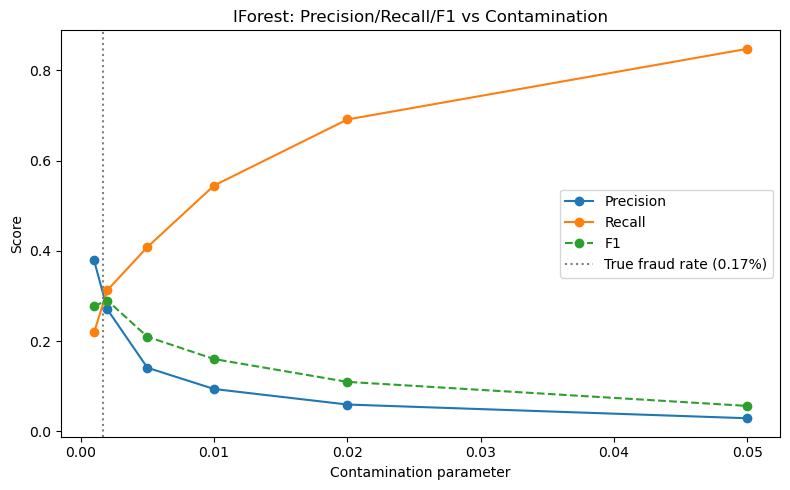

In [8]:
# ── Q3: Contamination sensitivity analysis ────────────────────────────────
# True fraud rate is 0.17%. What happens when contamination is wrong?
# Test IForest with contamination: 0.001, 0.002, 0.005, 0.01, 0.02, 0.05
# For each:
#   - Number flagged
#   - Precision (% of flagged that are fraud)
#   - Recall (% of fraud that is flagged)
#   - F1 score
# Plot Precision-Recall tradeoff as contamination increases
# What is the practical consequence of overestimating contamination?

from sklearn.metrics import f1_score

contamination_values = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
results_q3 = []

for c in contamination_values:
    model = IForest(contamination=c, n_estimators=100, random_state=420)
    model.fit(X_scaled)
    labels = model.labels_   # hard 0/1 predictions, based on this contamination's threshold

    n_flagged = int(labels.sum())
    precision = y[labels == 1].mean() if n_flagged > 0 else 0.0
    recall = y[labels == 1].sum() / y.sum()
    f1 = f1_score(y, labels)

    results_q3.append({
        'contamination': c, 'n_flagged': n_flagged,
        'precision': precision, 'recall': recall, 'f1': f1,
    })

comparison_q3 = pd.DataFrame(results_q3)
print(comparison_q3.round(4))

# ── Plot: Precision-Recall tradeoff as contamination increases ────────────
plt.figure(figsize=(8, 5))
plt.plot(comparison_q3['contamination'], comparison_q3['precision'], marker='o', label='Precision')
plt.plot(comparison_q3['contamination'], comparison_q3['recall'], marker='o', label='Recall')
plt.plot(comparison_q3['contamination'], comparison_q3['f1'], marker='o', label='F1', linestyle='--')
plt.axvline(0.0017, color='gray', linestyle=':', label='True fraud rate (0.17%)')
plt.xlabel('Contamination parameter')
plt.ylabel('Score')
plt.title('IForest: Precision/Recall/F1 vs Contamination')
plt.legend()
plt.tight_layout()
plt.show()

***Takeaway*** 

Contamination is a threshold knob, not a model parameter — it forces n_flagged ≈ contamination × n, so it directly trades precision for recall. 

F1 peaked at contamination=0.002 (0.290), right next to the true fraud rate (0.17%), then degraded as contamination overshot it. 

Overestimating contamination is costly in a specific, asymmetric way: precision collapses ~13x (0.379→0.029) while recall only gains ~4x (0.220→0.848) with strong diminishing returns — so the practical failure mode of guessing too high isn't "slightly worse," it's flooding the review queue with false alarms (~33 per real fraud caught at contamination=0.05) for a shrinking recall payoff. 

Bottom line: get contamination close to your real anomaly-rate estimate; don't pad it "to be safe."

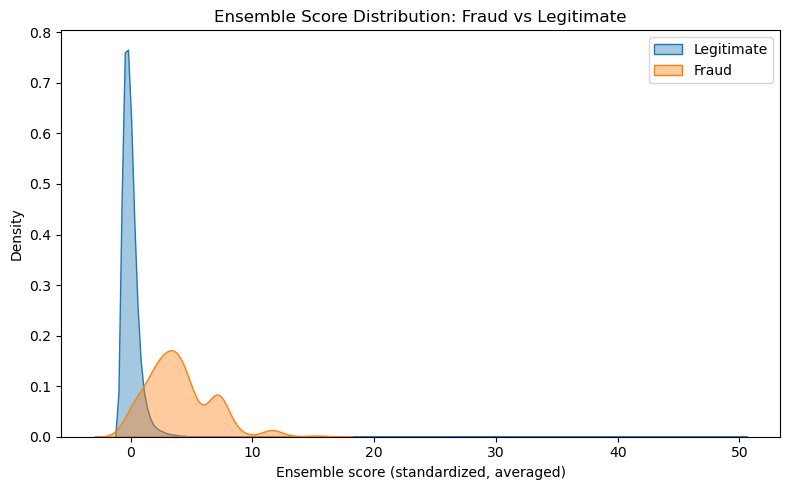

Operating point @ contamination=0.002: threshold=5.4692, n_flagged=570, precision=0.2035, recall=0.2358


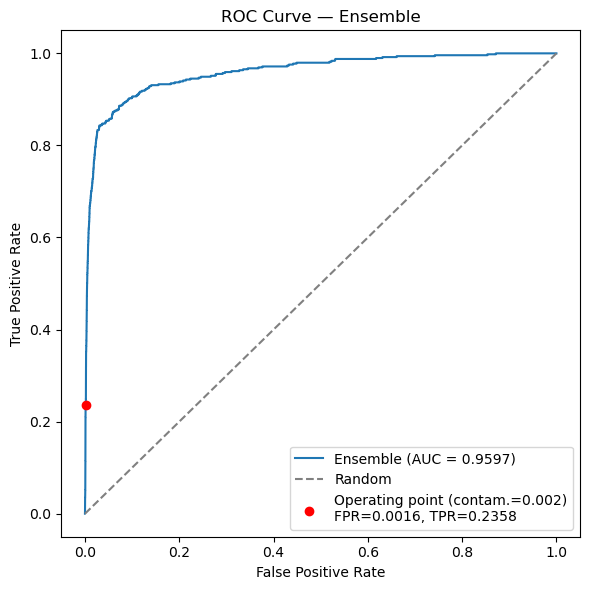

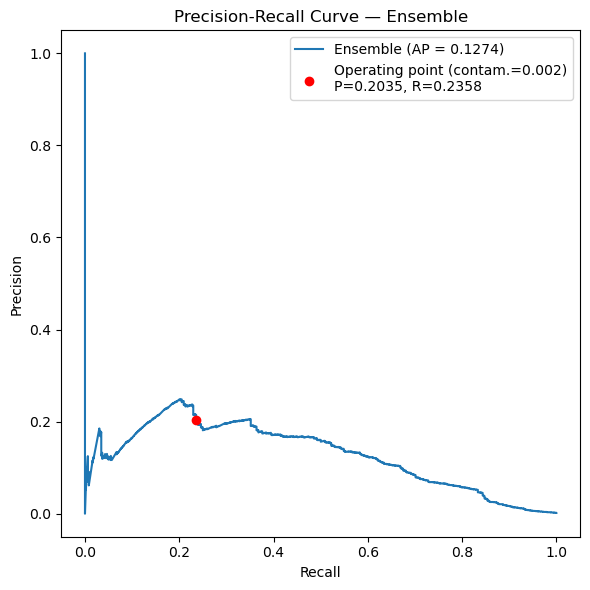


Method                              ROC-AUC       AP
Day 10 Mahalanobis (unsup.)          0.9574   0.5146
Day 11 HBOS alone (unsup.)           0.9524   0.2660
Day 11 Ensemble (unsup.)             0.9597   0.1274


In [9]:
# ── Q4: Score distribution visualization ──────────────────────────────────
# For the ensemble score:
#   1. Plot KDE of scores for fraud vs legitimate (overlapping, different colors)
#   2. Plot the ROC curve
#   3. Plot the Precision-Recall curve
#   4. Mark the operating point at contamination=0.002
#   5. What precision and recall does the ensemble achieve at this operating point?
#   6. How does this compare to our classification pipeline results from earlier?

import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve

# ── 1. KDE of ensemble scores: fraud vs legitimate ─────────────────────────
plt.figure(figsize=(8, 5))
sns.kdeplot(ensemble_score[y == 0], label='Legitimate', fill=True, alpha=0.4)
sns.kdeplot(ensemble_score[y == 1], label='Fraud', fill=True, alpha=0.4)
plt.xlabel('Ensemble score (standardized, averaged)')
plt.ylabel('Density')
plt.title('Ensemble Score Distribution: Fraud vs Legitimate')
plt.legend()
plt.tight_layout()
plt.show()

# ── 4-5. Operating point at contamination=0.002 (computed first, so we can
#         mark it on the curves below) ──────────────────────────────────────
contamination = 0.002
threshold_op = np.percentile(ensemble_score, 100 * (1 - contamination))
labels_op = (ensemble_score >= threshold_op).astype(int)

n_flagged_op = int(labels_op.sum())
precision_op = y[labels_op == 1].mean()
recall_op = y[labels_op == 1].sum() / y.sum()
fpr_op = labels_op[y == 0].sum() / (y == 0).sum()

print(f"Operating point @ contamination=0.002: threshold={threshold_op:.4f}, "
      f"n_flagged={n_flagged_op}, precision={precision_op:.4f}, recall={recall_op:.4f}")

# ── 2. ROC curve, with operating point marked ──────────────────────────────
fpr, tpr, _ = roc_curve(y, ensemble_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {ensemble_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.scatter([fpr_op], [recall_op], color='red', zorder=5,
            label=f'Operating point (contam.=0.002)\nFPR={fpr_op:.4f}, TPR={recall_op:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Ensemble')
plt.legend()
plt.tight_layout()
plt.show()

# ── 3. Precision-Recall curve, with operating point marked ────────────────
prec_curve, rec_curve, _ = precision_recall_curve(y, ensemble_score)

plt.figure(figsize=(6, 6))
plt.plot(rec_curve, prec_curve, label=f'Ensemble (AP = {ensemble_ap:.4f})')
plt.scatter([recall_op], [precision_op], color='red', zorder=5,
            label=f'Operating point (contam.=0.002)\nP={precision_op:.4f}, R={recall_op:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Ensemble')
plt.legend()
plt.tight_layout()
plt.show()

# ── 6. Compare to earlier results ──────────────────────────────────────────
print(f"\n{'Method':<32} {'ROC-AUC':>10} {'AP':>8}")
print(f"{'Day 10 Mahalanobis (unsup.)':<32} {0.9574:>10.4f} {0.5146:>8.4f}")
print(f"{'Day 11 HBOS alone (unsup.)':<32} {comparison_q1.loc['HBOS','ROC-AUC']:>10.4f} {comparison_q1.loc['HBOS','AP']:>8.4f}")
print(f"{'Day 11 Ensemble (unsup.)':<32} {ensemble_auc:>10.4f} {ensemble_ap:>8.4f}")


***Takeaway***

KDE: solid separation in shape — legit is sharply peaked near 0, fraud is shifted right (multimodal, humps around ~4, ~7, ~12) — but there's real overlap in the 0–3 range, which is exactly the region a hard 0.002 threshold has to cut through. That overlap is why precision/recall at the operating point aren't great even though the distributions look visually distinct.

Operating point (contamination=0.002): FPR=0.0016, recall=0.2358, precision=0.2035. Translation: at this threshold the ensemble catches only ~24% of fraud while flagging 2,035 out of every 10,000 review budget items as accurate hits. Despite AUC=0.9597 (the best of anything computed today), the usable operating point is mediocre — another concrete instance of AUC rewarding global rank-ordering while precision/recall reward what actually happens at the threshold you deploy.

The PR curve confirms the operating point is near-optimal for this score, sitting right at the curve's plateau (~0.20 precision) — so this isn't a badly-chosen threshold, it's the ceiling of what this ensemble's score distribution can deliver at that recall level.

The comparison table is the real story: the 5-detector ensemble has the best AUC (0.9597) but the worst AP (0.1274) of all three methods — worse than HBOS alone (0.2660) and less than a quarter of Day 10's simple Mahalanobis distance (0.5146). After a full day of building a "sophisticated" ML ensemble, the plain statistical Gaussian-distance method from Day 10 is still the best fraud-catcher on the metric that matters for this imbalanced problem. This directly closes the loop on the recurring theme across both weeks: sophistication only helps when it targets the actual weakness in your data, and naive unweighted averaging here diluted the ensemble's few good signals (HBOS) with its bad ones (LOF), same conclusion as Q2 — just now confirmed against the best available unsupervised baseline, not just against itself.